<a href="https://colab.research.google.com/github/pa24117-crypto/Birthday/blob/main/HW_2_ci_345.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [140]:
import pandas as pd
import numpy as np

In [141]:
from google.colab import drive

#Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# step 1: Load Data


In [142]:
diabetes_file = '/content/drive/MyDrive/CI345_ML/Data/diabetes.csv'

orginal_vtable = pd.read_csv(diabetes_file)
df = orginal_vtable
print(df.shape)
orginal_vtable.head(3)

(100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0


#Step 2: Basic Data Analysis


In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [144]:
print(df.shape)


(100000, 9)


In [145]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

In [146]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [147]:
df[['age', 'bmi']].describe()

,age,bmi
count,100000.000000,100000.000000
mean,41.885856,27.320767
std,22.516840,6.636783
min,0.080000,10.010000
25%,24.000000,23.630000
50%,43.000000,27.320000
75%,60.000000,29.580000
max,80.000000,95.690000


In [148]:
print("Mean:\n", df[['age', 'bmi']].mean())
print("Std:\n", df[['age', 'bmi']].std())
print("Min:\n", df[['age', 'bmi']].min())
print("Max:\n", df[['age', 'bmi']].max())

Mean:
 age    41.885856
bmi    27.320767
dtype: float64
Std:
 age    22.516840
bmi     6.636783
dtype: float64
Min:
 age     0.08
bmi    10.01
dtype: float64
Max:
 age    80.00
bmi    95.69
dtype: float64


#Step 3: Data Visualization: show following chart


<Axes: title={'center': 'abc'}, ylabel='count'>

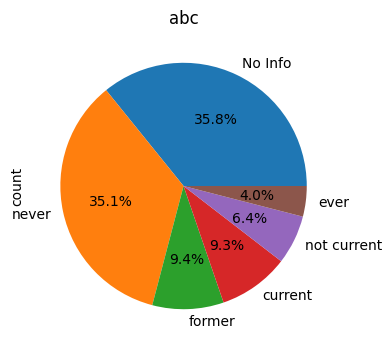

In [149]:
res = df['smoking_history'].value_counts()
res.plot(
    kind='pie',
    autopct='%1.1f%%',
    title='abc',
    figsize=(6, 4)
)

<Axes: title={'center': 'Performance in each level'}, xlabel='smoking_history'>

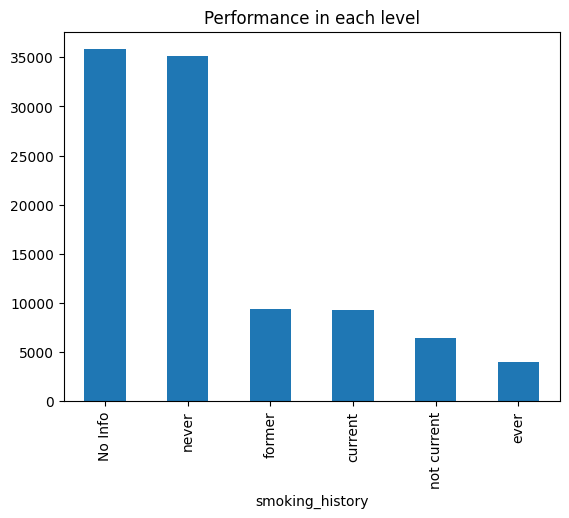

In [150]:
res = df['smoking_history'].value_counts()
res.plot(kind= 'bar', title = 'Performance in each level')

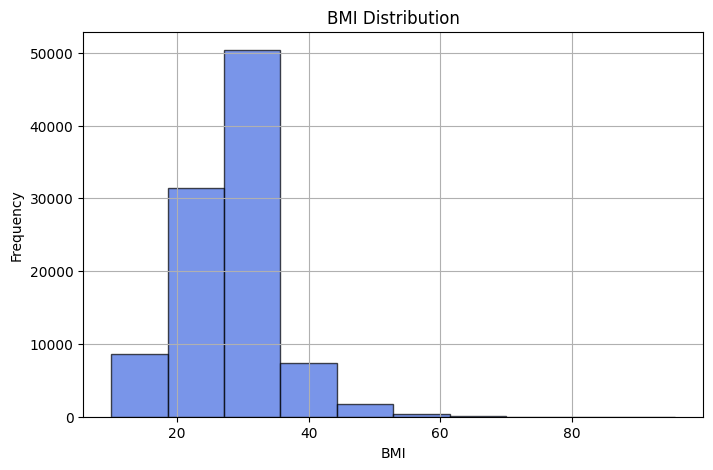

In [151]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df['bmi'], bins=10, edgecolor='black', color='royalblue', alpha=0.7)

plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Frequency')

plt.grid(True)

plt.show()

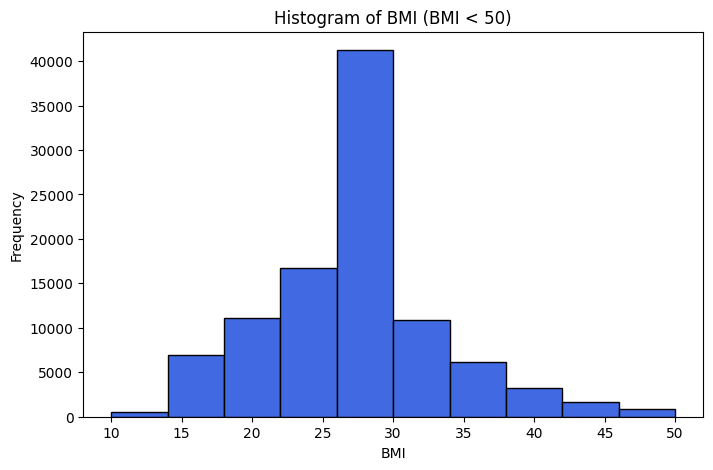

In [152]:
import pandas as pd
import matplotlib.pyplot as plt


filtered_df = df[df['bmi'] < 50]

plt.figure(figsize=(8,5))
plt.hist(filtered_df['bmi'], bins=10, edgecolor='black', color='royalblue')

plt.title('Histogram of BMI (BMI < 50)')
plt.xlabel('BMI')
plt.ylabel('Frequency')

plt.show()

array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'bmi'}>],
       [<Axes: title={'center': 'HbA1c_level'}>,
        <Axes: title={'center': 'blood_glucose_level'}>]], dtype=object)

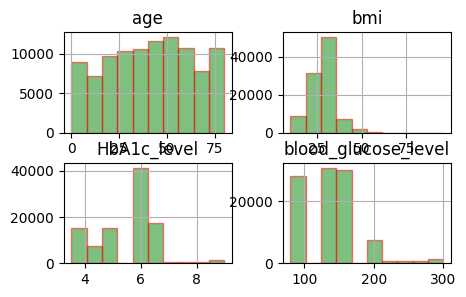

In [153]:

df = orginal_vtable
res = df[['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']]

res.hist(alpha=0.5,edgecolor='red', color = 'green', figsize=(5, 3))

diabetes
0    91500
1     8500
Name: count, dtype: int64


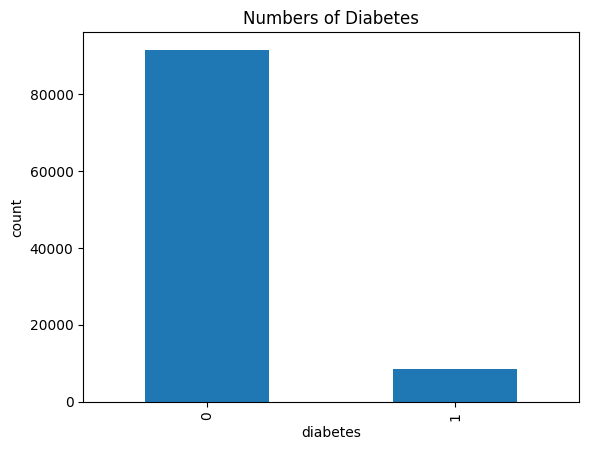

In [154]:

# Count diabetes values
count = df['diabetes'].value_counts().sort_index()

# Print counts
print(count)

# Plot graph
count.plot(kind='bar')

plt.title('Numbers of Diabetes')
plt.xlabel('diabetes')
plt.ylabel('count')

plt.show()

#Step 4: Data Processing

Method 1 : Using LabelEncoder for gender

In [155]:
df = orginal_vtable
print(df.gender.dtypes)
df.head(2)

object


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0


#Method 2: Using mapping for Smokeing_history

In [156]:
# Define mapping
hist_map = {
    'never': 0,
    'No Info': 2,
    'current': 10,
    'former': 8,
    'ever': 20,
    'not current': 5
}

# Create new numeric column
df['smoking_hist'] = df['smoking_history'].map(hist_map)

# Show first rows
print(df.head(2))

hist = {'never':0,'No Info':2,'current':10,'former':8,'ever':20,'not current':5}

df['smoking_history'] = df['smoking_history'].map(hist).fillna(df['smoking_history'])

df.head(2)

   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   

   HbA1c_level  blood_glucose_level  diabetes  smoking_hist  
0          6.6                  140         0             0  
1          6.6                   80         0             2  


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_hist
0,Female,80.0,0,1,0,25.19,6.6,140,0,0
1,Female,54.0,0,0,2,27.32,6.6,80,0,2


#Method 3: Using dummies


In [157]:
category_cols = ['gender', 'smoking_history']

df_use_dummies = pd.get_dummies(df, columns = category_cols , dtype = int)
print('________')
print(df_use_dummies.dtypes)
df_use_dummies.head(2)

________
age                    float64
hypertension             int64
heart_disease            int64
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
smoking_hist             int64
gender_Female            int64
gender_Male              int64
gender_Other             int64
smoking_history_0        int64
smoking_history_2        int64
smoking_history_5        int64
smoking_history_8        int64
smoking_history_10       int64
smoking_history_20       int64
dtype: object


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_hist,gender_Female,gender_Male,gender_Other,smoking_history_0,smoking_history_2,smoking_history_5,smoking_history_8,smoking_history_10,smoking_history_20
0,80.0,0,1,25.19,6.6,140,0,0,1,0,0,1,0,0,0,0,0
1,54.0,0,0,27.32,6.6,80,0,2,1,0,0,0,1,0,0,0,0


#Method 4: One-hot Encoder

In [159]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

ohe = OneHotEncoder()

encoded = ohe.fit_transform(df[['Gender']]).toarray()

encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(['Gender'])
)

encoded_df

KeyError: "None of [Index(['Gender'], dtype='object')] are in the [columns]"

#Step 5: Separate Data feature and target

In [ ]:
print(df.columns)
cols_used = ['gender', 'age', 'hypertension','heart_disease','smoking_hist', 'HbA1c_level', 'blood_glucose_level']

data =df[cols_used]

target = df['diabetes']

print(data.shape)
print(target.shape)
print(target.head(2))
data.head(3)

#Step 6: Training three classifiers

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd

df1 = pd.get_dummies(df, drop_first=True).fillna(0)

X = df1.drop('diabetes', axis=1)
y = df1['diabetes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

for k in [3,5,7]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    print("K =", k)
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

df1 = pd.get_dummies(df, drop_first=True).fillna(0)

X = df1.drop('diabetes', axis=1)
y = df1['diabetes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

In [ ]:
from sklearn import svm
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import pandas as pd

df1 = pd.get_dummies(df, drop_first=True).fillna(0)

X = df1.drop('diabetes', axis=1)
y = df1['diabetes']

data_train, data_test, target_train, target_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

svm_classifier = svm.SVC()

svm_classifier.fit(data_train, target_train)

predicted = svm_classifier.predict(data_test)

report = classification_report(target_test, predicted)
print(report)

matrix = confusion_matrix(target_test, predicted)
print(matrix)